<a href="https://colab.research.google.com/github/CIDE7/Ciencia-de-daos-iesb/blob/main/Vacinacao_2026_feito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados de Vacinação no Brasil - 2026

## Introdução

Os dados utilizados neste trabalho foram coletados em junho de 2026. Como a base é atualizada continuamente, os resultados podem apresentar diferenças em consultas realizadas em datas posteriores. Portanto, as análises apresentadas refletem exclusivamente o conjunto de dados disponível no momento da coleta. Os dados contêm informações sobre doses aplicadas, características dos pacientes e dos estabelecimentos de saúde responsáveis pela vacinação.

A base contém registros de vacinação entre janeiro e Maio de 2026.

O conjunto de dados pode ser classificado como dados estruturados, pois as informações estão organizadas em linhas e colunas, facilitando sua manipulação e análise utilizando ferramentas como Python e Pandas.

A escolha desse tema foi motivada pela relevância da vacinação para a saúde pública. Além disso, trata-se de um assunto que impacta diretamente a população e permite explorar diferentes tipos de análises, como distribuição por gênero, faixa etária, raça/cor, estado e categoria de atendimento.

O principal objetivo deste trabalho é aplicar conceitos introdutórios de Ciência de Dados para coletar, organizar, tratar e analisar informações reais, extraindo indicadores que possam auxiliar na compreensão do cenário de vacinação registrado na base de dados utilizada.

Durante a análise serão utilizadas bibliotecas da linguagem Python para manipulação dos dados, geração de tabelas e construção de gráficos que permitam visualizar os resultados de forma mais clara.


## Coleta dos Dados

Os dados foram obtidos por meio de uma API pública disponibilizada pelo Ministério da Saúde. A utilização de uma API permite acessar informações atualizadas de forma automatizada, sem a necessidade de download manual de arquivos.

Nesta etapa, foi realizada a coleta dos registros de vacinação e o armazenamento das informações em um DataFrame do Pandas para posterior análise.


In [20]:
import requests
import pandas as pd
import time

url = "https://apidadosabertos.saude.gov.br/vacinacao/doses-aplicadas-pni-2026"

limite = 1000
total_paginas = 25

dados = []

for pagina in range(total_paginas):

    offset = pagina * limite

    parametros = {
        "limit": limite,
        "offset": offset
    }

    resposta = requests.get(url, params=parametros, timeout=120)

    dados_api = resposta.json()

    registros = dados_api.get("doses_aplicadas_pni", [])

    if len(registros) == 0:
        break

    for item in registros:
        dados.append(item)

    time.sleep(1)

df = pd.DataFrame(dados)

print("Total de registros:", len(df))


Total de registros: 25000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 56 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   descricao_natureza_estabelecimento      25000 non-null  object
 1   codigo_via_administracao                25000 non-null  object
 2   nome_pais_paciente                      24595 non-null  object
 3   codigo_origem_registro                  1726 non-null   object
 4   codigo_pais_paciente                    24595 non-null  object
 5   nome_raca_cor_paciente                  25000 non-null  object
 6   sigla_vacina                            25000 non-null  object
 7   codigo_vacina_fabricante                24546 non-null  object
 8   data_vacina                             25000 non-null  object
 9   codigo_condicao_maternal                23789 non-null  object
 10  nome_razao_social_estabelecimento       25000 non-null  object
 11  si

1 -Quantidade de pacientes distintos que vacinaram agrupados por categoria de atendimento;

Este tópico apresenta a quantidade de pacientes distintos vacinados agrupados por estado, permitindo visualizar a distribuição da vacinação entre as unidades federativas do país. A análise possibilita identificar os estados com maior número de pessoas imunizadas, contribuindo para a avaliação da cobertura vacinal e para o planejamento de estratégias de saúde pública em diferentes regiões.

In [22]:
#1 Pacientes por categoria de atendimento

resultado = df.groupby(
    "descricao_vacina_categoria_atendimento"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["categoria", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)

print("Total de categorias:", len(resultado))
print("Total de pacientes:", df["codigo_paciente"].nunique())


                                          categoria  qtd_pacientes
1                                      Faixa Etária          20381
16                           Trabalhadores de Saúde           1142
5                                         Gestantes            754
0                                      Comorbidades            723
10                                  Povos Indígenas             81
12                                        Puérperas             17
9                    População Privada de Liberdade             16
14                        Trabalhadores da Educação             14
6                                            Outros             13
11                 Povos e Comunidades Tradicionais              9
17                      Trabalhadores de Transporte              8
3                  Forças de Segurança e Salvamento              5
13                        Trabalhadores Industriais              3
4   Funcionário do Sistema de Privação de Liberdade           

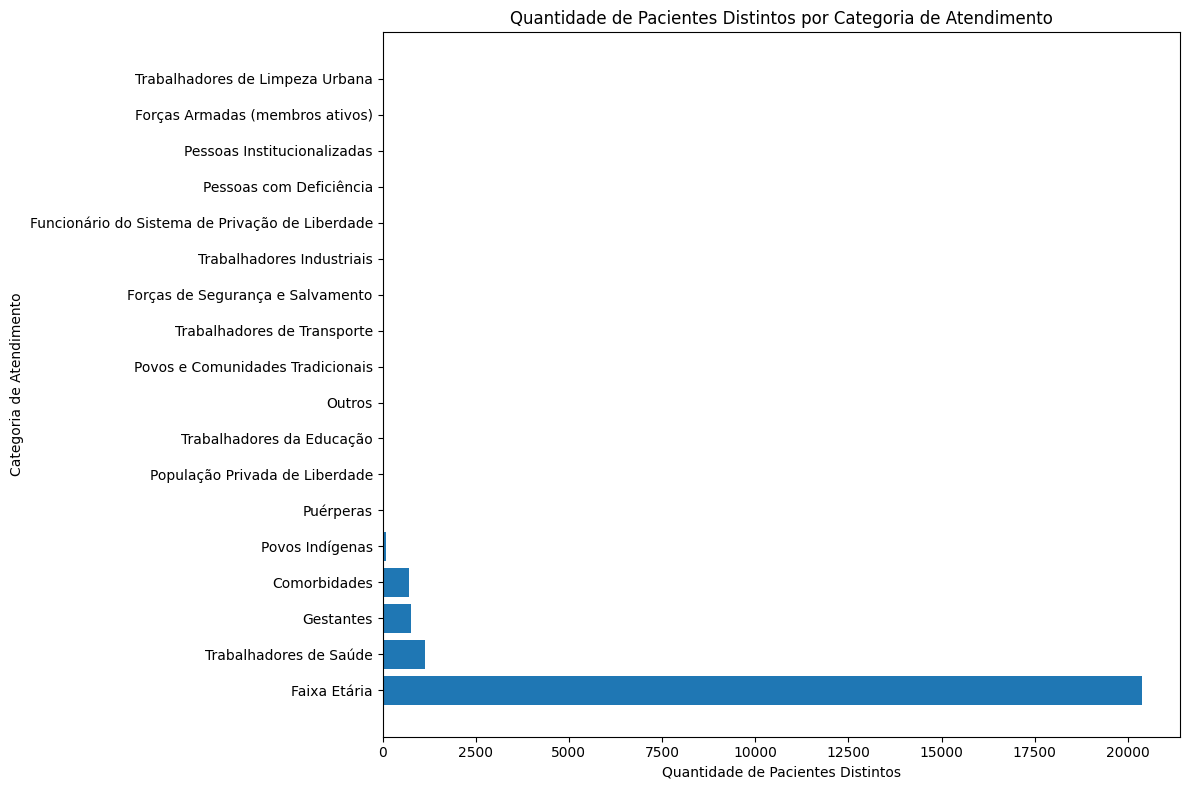

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.barh(
    resultado['categoria'],
    resultado['qtd_pacientes']
)

plt.title('Quantidade de Pacientes Distintos por Categoria de Atendimento')
plt.xlabel('Quantidade de Pacientes Distintos')
plt.ylabel('Categoria de Atendimento')

plt.tight_layout()
plt.show()

2 - Quantidade de pacientes distintos que vacinaram agrupado por Estado;
 Este tópico apresenta a distribuição das vacinas aplicadas entre os estados brasileiros, permitindo identificar regiões com maior cobertura vacinal. A análise auxilia na compreensão de desigualdades regionais e na avaliação da eficiência das campanhas de imunização.

In [24]:
#2 Pacientes por estado

resultado = df.groupby(
    "nome_uf_estabelecimento"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["estado", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)


                 estado  qtd_pacientes
24            SAO PAULO           6686
12         MINAS GERAIS           2552
18       RIO DE JANEIRO           1643
15               PARANA           1273
1               ALAGOAS           1169
3              AMAZONAS           1139
4                 BAHIA           1063
20    RIO GRANDE DO SUL            958
5                 CEARA            938
16           PERNAMBUCO            849
8                 GOIAS            770
13                 PARA            703
23       SANTA CATARINA            666
9              MARANHAO            641
6      DISTRITO FEDERAL            554
11   MATO GROSSO DO SUL            477
7        ESPIRITO SANTO            456
10          MATO GROSSO            408
17                PIAUI            354
14              PARAIBA            338
19  RIO GRANDE DO NORTE            329
25              SERGIPE            267
21             RONDONIA            244
26            TOCANTINS            212
0                  ACRE  

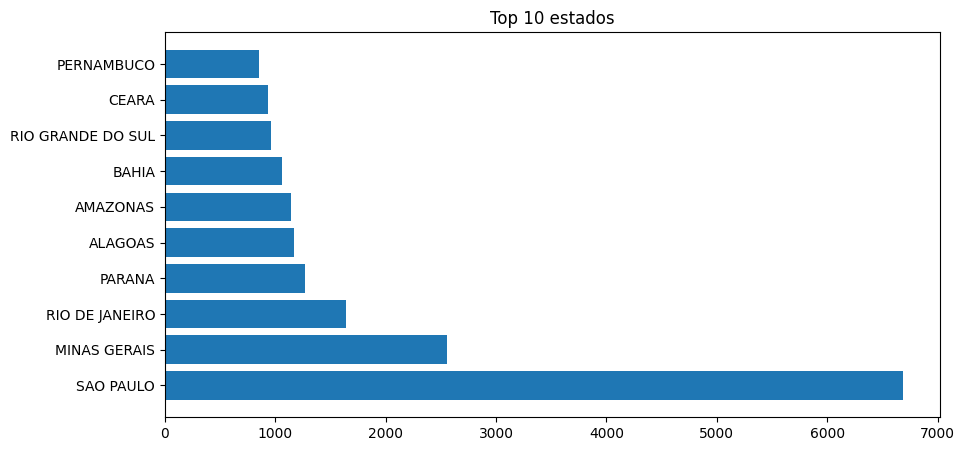

In [25]:
import matplotlib.pyplot as plt

resultado = df.groupby(
    "nome_uf_estabelecimento"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["estado", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

top10 = resultado.head(10)

plt.figure(figsize=(10,5))
plt.barh(top10["estado"], top10["qtd_pacientes"])
plt.title("Top 10 estados")
plt.show()


3 - Quantidade de pacientes distintos que vacinaram agrupados por raça e cor;
🧑🏾‍🤝‍🧑🏻 Doses por Raça/Cor

Este gráfico mostra a distribuição das doses aplicadas por raça/cor, com predominância nas categorias parda e branca.

         raca_cor  qtd_pacientes
3           PARDA           9380
1          BRANCA           8079
5  SEM INFORMACAO           5695
0         AMARELA           1128
4           PRETA            576
2        INDIGENA             80


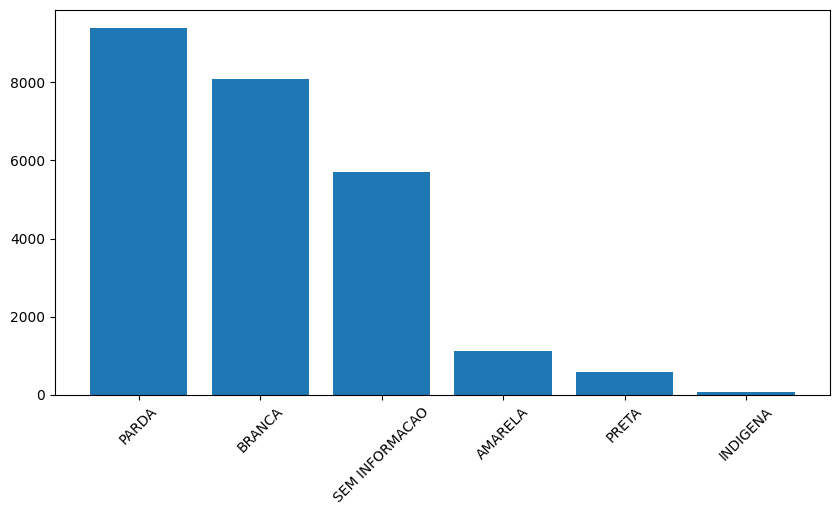

In [26]:
#3 pacientes agrupados por raça e cor

import matplotlib.pyplot as plt

resultado = df.groupby(
    "nome_raca_cor_paciente"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["raca_cor", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)

plt.figure(figsize=(10,5))
plt.bar(resultado["raca_cor"], resultado["qtd_pacientes"])
plt.xticks(rotation=45)
plt.show()


4- Quantidade de pacientes dististos agrupados por faixa etaria;

A distribuição de pacientes distintos por faixa etária permite identificar quais grupos populacionais foram mais alcançados pela vacinação. Essa análise evidencia padrões importantes, como maior cobertura em públicos prioritários ou maior adesão em determinadas idades, contribuindo para a avaliação da efetividade das estratégias de imunização ao longo do período analisado.

   faixa  qtd_pacientes
0    0-9          11156
1  10-19           5048
2  20-29           1385
3  30-39           1532
4  40-49           1091
5  50-59            871
6  60-69            703
7  70-79            493
8  80-89            193
9    90+             31


/tmp/ipykernel_29345/3829580134.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resultado = df.groupby("faixa_etaria")["codigo_paciente"].nunique()


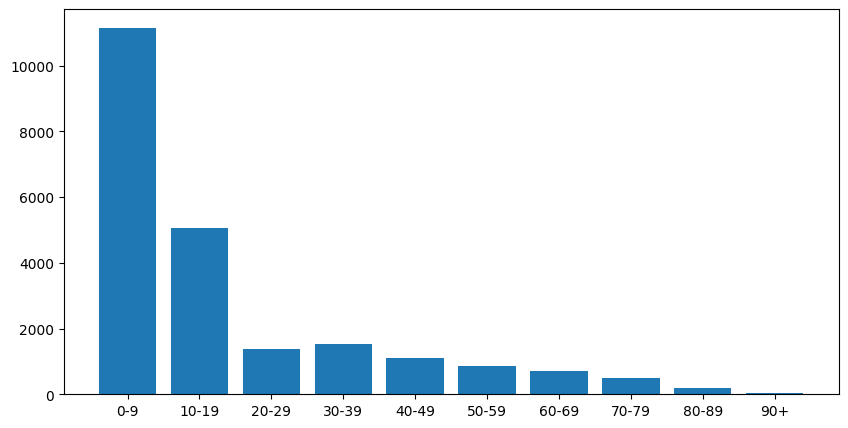

In [27]:
#4 pacientes agrupados por faixa etaria

import pandas as pd
import matplotlib.pyplot as plt

df["idade"] = pd.to_numeric(
    df["numero_idade_paciente"],
    errors="coerce"
)

bins = [0,9,19,29,39,49,59,69,79,89,200]
labels = ["0-9","10-19","20-29","30-39","40-49","50-59","60-69","70-79","80-89","90+"]

df["faixa_etaria"] = pd.cut(
    df["idade"],
    bins=bins,
    labels=labels
)

resultado = df.groupby("faixa_etaria")["codigo_paciente"].nunique()
resultado = resultado.reset_index()
resultado.columns = ["faixa", "qtd_pacientes"]

print(resultado)

plt.figure(figsize=(10,5))
plt.bar(resultado["faixa"], resultado["qtd_pacientes"])
plt.show()


5- Descrição do tipo de vacina;

Neste gráfico é possível observar que a vacina Pfizer (Comirnaty) foi a mais aplicada no período analisado, seguida por AstraZeneca e CoronaVac. Também aparecem versões específicas como vacinas pediátricas e bivalentes, indicando diversidade de imunizantes utilizados na campanha.

In [28]:
#5 - descricao_vacina

resultado = df.groupby(
    "descricao_vacina"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["vacina", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)


                                               vacina  qtd_pacientes
17                                Vacina meningo ACWY          11993
21                   Vacina sarampo, caxumba, rubéola           3027
22        Vacina sarampo, caxumba, rubéola e varicela           2476
1   Vacina COVID-19 PFIZER - COMIRNATY PEDIÁTRICA ...           2356
6                  Vacina Herpes-Zoster, recombinante           1053
9   Vacina Vírus Sincicial Respiratório A e B (rec...            941
7                                    Vacina Pneumo 20            903
5                            Vacina HPV quadrivalente            882
13                           Vacina hepatite A adulto            479
16                      Vacina influenza tetravalente            367
2            Vacina COVID-19 PFIZER - COMIRNATY, RNAm            251
18                                   Vacina meningo B            159
8   Vacina Vírus Sincicial Respiratório (recombina...             72
3   Vacina COVID-19 SINOVAC/BUTANT

6- Quantidade de doses por pacientes distintos;

A análise da quantidade de doses em relação ao número de pacientes distintos permite avaliar o alcance real da vacinação na população. Enquanto o total de doses indica o volume de aplicações realizadas, o número de indivíduos únicos mostra quantas pessoas foram efetivamente atendidas. A diferença entre esses valores reflete a aplicação de esquemas vacinais completos, incluindo doses adicionais e de reforço, sendo um indicador importante da continuidade e efetividade da imunização.

In [29]:
#6 - descricao_dose_vacina

resultado = df.groupby(
    "descricao_dose_vacina"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["dose", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)


                                     dose  qtd_pacientes
10                                Reforço           6625
12                                  Única           4968
8                                    Dose           4156
0                                 1ª Dose           3922
2                                 2ª Dose           3890
4                                 3ª Dose           1148
1                              1º Reforço            183
3                              2º Reforço             44
11                            Revacinação             35
6                                 4ª Dose             11
9   Profilaxia com 1 frasco-ampola/ampola              3
7                                 5ª Dose              1
5                              3º Reforço              1


7- Gêneros dos pacientes;

A análise dos gêneros dos pacientes permite compreender a distribuição da vacinação entre os diferentes grupos, evidenciando possíveis diferenças no acesso ou na adesão à imunização. Essa informação é relevante para identificar padrões populacionais e apoiar estratégias mais inclusivas e equitativas nas campanhas de vacinação.

  genero  qtd_pacientes
0      F          13097
1      M          11841


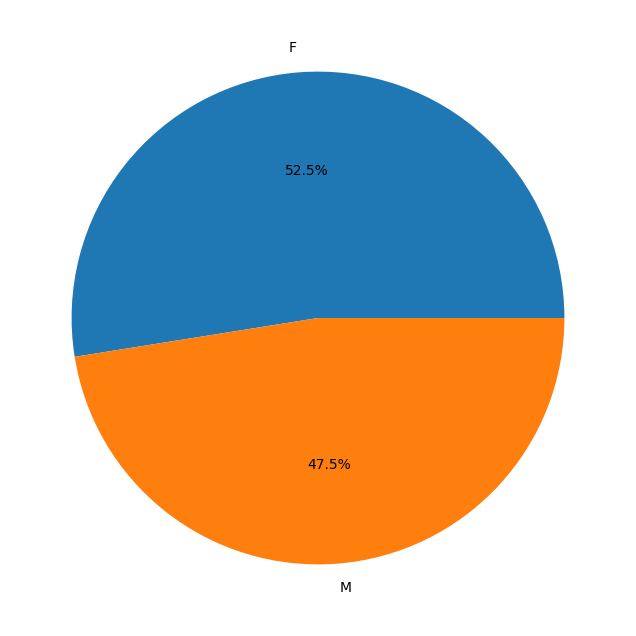

In [30]:
#7 - tipo_genero_paciente

import matplotlib.pyplot as plt

resultado = df.groupby(
    "tipo_sexo_paciente"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["genero", "qtd_pacientes"]

print(resultado)

plt.figure(figsize=(8,8))
plt.pie(
    resultado["qtd_pacientes"],
    labels=resultado["genero"],
    autopct="%1.1f%%"
)
plt.show()

8- Tipo de estabelecimento;


“Tipo de estabelecimento” é uma classificação usada para identificar a natureza ou atividade principal de um local ou empresa.

In [31]:
#8 descricao_tipo_estabelecimento

resultado = df.groupby(
    "descricao_tipo_estabelecimento"
).size()

resultado = resultado.reset_index()
resultado.columns = ["tipo_estabelecimento", "quantidade"]

resultado = resultado.sort_values(
    "quantidade",
    ascending=False
)

print(resultado)


                                 tipo_estabelecimento  quantidade
5                      CENTRO DE SAUDE/UNIDADE BASICA       19164
6                     CLINICA/CENTRO DE ESPECIALIDADE        1445
3                                CENTRO DE IMUNIZACAO        1102
8                                            FARMACIA         553
18  UNIDADE DE APOIO DIAGNOSE E TERAPIA (SADT ISOL...         540
12                                        POLICLINICA         534
14                                     POSTO DE SAUDE         479
7                                 CONSULTORIO ISOLADO         367
10                                     HOSPITAL GERAL         319
9                              HOSPITAL ESPECIALIZADO          87
0                            CENTRAL DE ABASTECIMENTO          76
19                UNIDADE DE ATENCAO A SAUDE INDIGENA          75
1                          CENTRAL DE GESTAO EM SAUDE          64
20                     UNIDADE DE VIGILANCIA EM SAUDE          44
21        